# ⚾ 재대결에서 같은 구종은 어떻게 달라졌나: 코스·무브먼트·구속 시각화

* **작성자:** DY
* **작성일:** 2026-09-26
* **목적:**
  * 장타를 허용한 구종을 같은 타자와의 재대결 타석에서 다시 던졌을 때, 직전(장타) 타석과 비교해 같은 구종의 코스·무브먼트·구속이 어떻게 달라졌는지 봅니다.
  * 투수 손(우투/좌투)별로 그림을 나누고(같은 구종이라도 손에 따라 궤적이 다름), 장타 허용 타석과 재대결 타석을 색으로, 구종별로 행을 나눠 보여 줍니다.
* **한계:** 대조군이 없어 변화가 "장타 반응"이라고 단정할 수 없습니다. 자세한 한계는 맨 아래에 정리했습니다.

In [1]:
# 1. 경로 설정 (src 폴더 접근용)
import sys, os
sys.path.append(os.path.abspath('..'))

# 2. Autoreload 설정 (src 내부의 py 파일 수정 시 즉시 반영)
%load_ext autoreload
%autoreload 2

# 경고 메시지 무시 (선택 사항)
import warnings
warnings.filterwarnings('ignore')

import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from scipy import stats

from src.preprocessing.build_next_ab_dataset import (
    build_event_dataset_for_events,
    filter_to_same_batter_rematch,
    identify_extra_base_hit_events,
)
from src.preprocessing.research_sample import KEY_COLUMNS, list_research_csvs
from src.visualization.pitch_type_reuse_plots import LABELS, XBH_COLOR, _use_korean_font

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
_use_korean_font()

## 1. 팀 CSV 읽기와 재대결 이벤트

`data/raw` 없이 팀 research CSV를 그대로 읽습니다. 2026-10-01부터 CSV에 `home_score`/`away_score`가 추가돼
실제 점수로 이벤트를 만들 수 있지만, 이 노트북은 코스·무브먼트·구속만 보므로 `score_diff`는 바로 버립니다.

In [2]:
MEASURES = ['plate_x', 'plate_z', 'pfx_x', 'pfx_z', 'release_speed', 'release_spin_rate', 'release_extension']
LOAD_COLUMNS = [
    'game_pk', 'game_date', 'at_bat_number', 'pitch_number', 'pitcher', 'player_name', 'batter',
    'stand', 'p_throws', 'pitch_type', 'events', 'balls', 'strikes', 'outs_when_up',
    'inning', 'inning_topbot', 'home_score', 'away_score', *MEASURES,
]


def load_team_csv() -> pd.DataFrame:
    frames = [
        pd.read_csv(path, usecols=LOAD_COLUMNS, encoding='utf-8-sig', low_memory=False)
        for path in list_research_csvs()
    ]
    pitches = pd.concat(frames, ignore_index=True)
    pitches['season'] = pd.to_datetime(pitches['game_date']).dt.year
    return pitches


pitches = load_team_csv()
assert len(pitches) == 3_592_302 and pitches['pitcher'].nunique() == 1_067
assert not pitches.duplicated(KEY_COLUMNS).any()

xbh_all = identify_extra_base_hit_events(pitches)
candidates = filter_to_same_batter_rematch(pitches, xbh_all)
events = build_event_dataset_for_events(pitches, candidates, next_pa_mode='same_batter').drop(columns='score_diff')
assert len(xbh_all) == 70_319 and len(events) == 27_391

reused = events[events['has_next_ab'] & (events['reused_same_type'] == 1)].reset_index(drop=True)
print(f'장타 {len(xbh_all):,}건 -> 같은 타자 재대결 {len(events):,}건 -> 같은 구종 재사용 {len(reused):,}건')
assert len(reused) == 12_459, len(reused)

장타 70,319건 -> 같은 타자 재대결 27,391건 -> 같은 구종 재사용 12,459건


## 2. 같은 구종 투구 모으기

이벤트마다 (1) 장타 타석에서 그 투수가 던진 같은 구종 투구 전부(`hit_pa`, 실제 장타가 된 투구는 `is_event_pitch`)와
(2) 재대결 타석에서 그 투수가 던진 같은 구종 투구 전부(`rematch_pa`)를 모읍니다.

In [3]:
def collect_pa_pitches(pitches_: pd.DataFrame, events_: pd.DataFrame) -> pd.DataFrame:
    keys = ['game_pk', 'pitcher']
    ev = events_[keys + ['hit_pitch_type', 'p_throws', 'stand', 'at_bat_number', 'event_pitch_number', 'next_at_bat_number']].copy()
    ev['event_id'] = np.arange(len(ev))
    ev['next_at_bat_number'] = ev['next_at_bat_number'].astype(int)
    ev = ev.rename(columns={'at_bat_number': 'hit_at_bat'})
    px = pitches_[keys + ['pitch_type', 'at_bat_number', 'pitch_number', *MEASURES]].rename(
        columns={'pitch_type': 'hit_pitch_type'}
    )
    joined = ev.merge(px, on=keys + ['hit_pitch_type'], how='inner')  # 그 경기에서 그 투수의 같은 구종 투구 전부
    in_hit_pa = joined['at_bat_number'] == joined['hit_at_bat']
    in_rematch_pa = joined['at_bat_number'] == joined['next_at_bat_number']
    out = joined[in_hit_pa | in_rematch_pa].copy()
    out['phase'] = np.where(out['at_bat_number'] == out['hit_at_bat'], 'hit_pa', 'rematch_pa')
    out['is_event_pitch'] = (out['phase'] == 'hit_pa') & (out['pitch_number'] == out['event_pitch_number'])
    return out.drop(columns=['hit_at_bat', 'next_at_bat_number', 'event_pitch_number']).reset_index(drop=True)

In [4]:
_px = pd.DataFrame({
    'game_pk': [1] * 6, 'pitcher': [10] * 6,
    'pitch_type': ['SL', 'FF', 'SL', 'SL', 'FF', 'SL'],
    'at_bat_number': [5, 5, 5, 9, 9, 9], 'pitch_number': [1, 2, 3, 1, 2, 3],
    'plate_x': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6], 'plate_z': [2.0, 2.1, 2.2, 2.3, 2.4, 2.5],
    'pfx_x': [0.0] * 6, 'pfx_z': [0.0] * 6, 'release_speed': [85.0, 95.0, 86.0, 87.0, 96.0, 88.0],
    'release_spin_rate': [2500.0] * 6, 'release_extension': [6.0] * 6,
})
_ev = pd.DataFrame({
    'game_pk': [1], 'pitcher': [10], 'hit_pitch_type': ['SL'], 'p_throws': ['R'], 'stand': ['L'],
    'at_bat_number': [5], 'event_pitch_number': [3], 'next_at_bat_number': [9.0],
})
_out = collect_pa_pitches(_px, _ev)
assert len(_out) == 4
assert sorted(_out['phase'].tolist()) == ['hit_pa', 'hit_pa', 'rematch_pa', 'rematch_pa']
assert _out.loc[_out['is_event_pitch'], 'plate_x'].tolist() == [0.3]      # 장타가 된 투구 (5타석 3구)
assert set(_out['release_speed']) == {85.0, 86.0, 87.0, 88.0}            # FF는 제외
assert _out['p_throws'].eq('R').all() and _out['event_id'].eq(0).all()
print('collect_pa_pitches 테스트 통과')

collect_pa_pitches 테스트 통과


In [5]:
pa = collect_pa_pitches(pitches, reused)
assert pa['event_id'].nunique() == len(reused)
assert pa.groupby('event_id')['is_event_pitch'].sum().eq(1).all(), '이벤트마다 장타가 된 투구가 정확히 1개여야 함'
assert (pa.groupby(['event_id', 'phase']).size().unstack('phase').notna().all().all()), '양쪽 타석 모두 투구가 있어야 함'
print(f'투구 {len(pa):,}개 (장타 타석 {(pa.phase == "hit_pa").sum():,}, 재대결 타석 {(pa.phase == "rematch_pa").sum():,})')
display(pa.groupby(['p_throws', 'hit_pitch_type'])['event_id'].nunique().unstack('p_throws').fillna(0).astype(int)
        .sort_values('R', ascending=False))

투구 45,611개 (장타 타석 25,227, 재대결 타석 20,384)


p_throws,L,R
hit_pitch_type,,
FF,1816,4295
SI,581,1546
SL,295,954
CH,342,567
FC,263,540
ST,90,359
CU,139,259
FS,13,170
KC,30,139


## 3. 이벤트별 변화와 수치표

이벤트마다 (재대결 타석 같은 구종 평균) − (장타 타석 같은 구종 평균)을 구하고, 구종 × 투수 손별로 평균 변화와 95% 신뢰구간(정규근사)을 냅니다.
코스는 ft, 무브먼트와 익스텐션은 인치(×12)로 환산합니다.

In [6]:
def event_deltas(pa_: pd.DataFrame) -> pd.DataFrame:
    means = pa_.groupby(['event_id', 'phase'])[MEASURES].mean().unstack('phase')
    delta = means.xs('rematch_pa', axis=1, level='phase') - means.xs('hit_pa', axis=1, level='phase')
    meta = pa_.groupby('event_id')[['p_throws', 'stand', 'hit_pitch_type']].first()
    return meta.join(delta)


def mean_ci(s: pd.Series) -> tuple[float, float, float]:
    s = s.dropna()
    n = len(s)
    m = s.mean()
    half = 1.96 * s.std(ddof=1) / np.sqrt(n) if n > 1 else float('nan')
    return m, m - half, m + half


DELTA_LABELS = {
    'plate_x': ('코스 x (ft)', 1), 'plate_z': ('코스 z (ft)', 1),
    'pfx_x': ('무브먼트 x (in)', 12), 'pfx_z': ('무브먼트 z (in)', 12),
    'release_speed': ('구속 (mph)', 1), 'release_spin_rate': ('회전수 (rpm)', 1),
    'release_extension': ('익스텐션 (in)', 12),
}


def summary_table(deltas_: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (hand, ptype), g in deltas_.groupby(['p_throws', 'hit_pitch_type']):
        row = {'p_throws': hand, 'hit_pitch_type': ptype, 'n_events': len(g)}
        for col, (label, scale) in DELTA_LABELS.items():
            m, lo, hi = mean_ci(g[col] * scale)
            row[f'{label} 평균변화'] = m
            row[f'{label} 95%CI'] = f'[{lo:.2f}, {hi:.2f}]'
        rows.append(row)
    return pd.DataFrame(rows).sort_values(['p_throws', 'n_events'], ascending=[True, False]).reset_index(drop=True)

In [7]:
_d = event_deltas(_out)
assert np.isclose(_d.loc[0, 'plate_x'], 0.3) and np.isclose(_d.loc[0, 'release_speed'], 2.0)
assert _d.loc[0, 'hit_pitch_type'] == 'SL' and _d.loc[0, 'p_throws'] == 'R'

_m, _lo, _hi = mean_ci(pd.Series([1.0, 2.0, 3.0]))
assert np.isclose(_m, 2.0) and np.isclose(_hi - _m, 1.96 / np.sqrt(3)) and np.isclose(_m - _lo, 1.96 / np.sqrt(3))

_dd = pd.DataFrame({
    'p_throws': ['R', 'R'], 'hit_pitch_type': ['SL', 'SL'], 'stand': ['R', 'L'],
    **{c: [0.2, 0.4] for c in MEASURES},
})
_s = summary_table(_dd)
assert len(_s) == 1 and _s.loc[_s.index[0], 'n_events'] == 2
assert np.isclose(_s.loc[_s.index[0], '코스 x (ft) 평균변화'], 0.3)
assert np.isclose(_s.loc[_s.index[0], '무브먼트 x (in) 평균변화'], 0.3 * 12)   # ft -> in 환산
print('변화·요약표 테스트 통과')

변화·요약표 테스트 통과


In [8]:
deltas = event_deltas(pa)
assert len(deltas) == len(reused)
table = summary_table(deltas)
display(table)
table.to_csv('../data/processed/rematch_execution_summary.csv', index=False)

,p_throws,hit_pitch_type,n_events,코스 x (ft) 평균변화,코스 x (ft) 95%CI,코스 z (ft) 평균변화,코스 z (ft) 95%CI,무브먼트 x (in) 평균변화,무브먼트 x (in) 95%CI,무브먼트 z (in) 평균변화,무브먼트 z (in) 95%CI,구속 (mph) 평균변화,구속 (mph) 95%CI,회전수 (rpm) 평균변화,회전수 (rpm) 95%CI,익스텐션 (in) 평균변화,익스텐션 (in) 95%CI
0,L,FF,1816,0.019773,"[-0.02, 0.06]",0.183400,"[0.15, 0.22]",-0.042894,"[-0.15, 0.06]",-0.012447,"[-0.10, 0.07]",0.004945,"[-0.06, 0.07]",6.619316,"[1.88, 11.36]",0.197227,"[0.11, 0.28]"
1,L,SI,581,0.003139,"[-0.06, 0.07]",0.028954,"[-0.03, 0.09]",0.146593,"[-0.03, 0.32]",-0.476014,"[-0.68, -0.27]",-0.078791,"[-0.18, 0.02]",2.169151,"[-10.07, 14.41]",0.202835,"[0.05, 0.36]"
2,L,CH,342,0.295738,"[0.21, 0.38]",-0.186977,"[-0.28, -0.09]",0.394813,"[0.15, 0.64]",-0.146257,"[-0.46, 0.16]",0.127052,"[-0.02, 0.28]",4.532304,"[-9.27, 18.33]",0.139707,"[-0.07, 0.35]"
3,L,SL,295,-0.108650,"[-0.19, -0.02]",-0.202263,"[-0.30, -0.10]",-0.130554,"[-0.42, 0.16]",-0.085499,"[-0.41, 0.24]",-0.176477,"[-0.39, 0.04]",5.851089,"[-8.28, 19.98]",0.297414,"[0.07, 0.53]"
4,L,FC,263,0.058790,"[-0.05, 0.17]",-0.008425,"[-0.11, 0.09]",-0.196190,"[-0.52, 0.12]",-0.143399,"[-0.47, 0.18]",-0.255330,"[-0.45, -0.06]",2.201521,"[-9.07, 13.48]",0.185399,"[-0.09, 0.46]"
5,L,CU,139,-0.249444,"[-0.39, -0.11]",-0.476509,"[-0.64, -0.31]",0.086547,"[-0.32, 0.49]",0.290504,"[-0.12, 0.70]",0.079736,"[-0.19, 0.35]",-1.411232,"[-21.09, 18.26]",0.658696,"[0.27, 1.04]"
6,L,ST,90,-0.197352,"[-0.40, 0.01]",-0.201051,"[-0.43, 0.02]",0.053206,"[-0.78, 0.89]",0.764714,"[0.05, 1.48]",0.053532,"[-0.32, 0.43]",-4.501058,"[-27.11, 18.11]",0.467460,"[0.00, 0.93]"
7,L,KC,30,-0.086640,"[-0.38, 0.21]",-0.358606,"[-0.74, 0.02]",-0.625667,"[-1.41, 0.15]",0.786000,"[0.17, 1.40]",0.010278,"[-0.52, 0.54]",-60.722222,"[-119.38, -2.06]",0.616667,"[-0.39, 1.62]"
8,L,SV,16,-0.452416,"[-0.99, 0.09]",-0.051729,"[-0.77, 0.67]",-0.337500,"[-2.09, 1.41]",0.560625,"[-0.99, 2.11]",0.665104,"[-0.01, 1.34]",-6.864583,"[-53.72, 39.99]",0.331250,"[-0.80, 1.46]"
9,L,FS,13,-0.019160,"[-0.49, 0.45]",-0.518422,"[-1.21, 0.18]",0.636462,"[-2.43, 3.71]",-0.442308,"[-2.09, 1.21]",-0.269487,"[-0.82, 0.28]",-14.155128,"[-84.73, 56.42]",0.933846,"[-0.21, 2.07]"


## 4. 그림

투수 손별로 그림 한 장씩. 행 = 구종(손별로 이벤트 50건 이상인 구종만), 열 = 코스 · 무브먼트 · 구속.

* 색: 장타 허용 타석 = 주황, 재대결 타석 = 파랑. 실제로 장타가 된 투구는 별표(★)
* 점: 투구 하나하나(투명도 적용, 색마다 최대 1,500개 무작위 표시), 별표는 이벤트마다 1개라 많으면 다른 점을 가려서 **무작위 250개까지만** 표시,
  얇은 등고선: 밀집 영역 50%, 큰 원과 십자: 이벤트 단위 평균과 95% 신뢰구간(모든 이벤트 기준, 표시 개수와 무관)
* 무브먼트 축은 자료의 0.5–99.5% 범위에 맞췄습니다(극단값은 잘림).
* 스트라이크 존은 타자별 상하한(`sz_top/sz_bot`)이 데이터에 없어 **고정 사각형**(좌우 ±0.83 ft, 높이 1.5–3.5 ft)입니다. 실제 존은 타자마다 다릅니다.
* 코스와 무브먼트는 포수 시점(오른쪽 = 1루 쪽)입니다. 타자 좌/우는 나누지 않고 섞어서 그립니다.

In [9]:
ZONE_HALF_WIDTH, ZONE_Z = 0.83, (1.5, 3.5)
PHASE_COLORS = {'hit_pa': XBH_COLOR, 'rematch_pa': '#0072B2'}
PHASE_LABELS = {'hit_pa': '장타 허용 타석', 'rematch_pa': '재대결 타석'}
PITCH_LABELS = {
    **LABELS, 'FS': '스플리터 (FS)', 'KC': '너클커브 (KC)', 'SV': '슬러브 (SV)', 'KN': '너클볼 (KN)', 'FO': '포크볼 (FO)',
}
HAND_LABELS = {'R': '우투수', 'L': '좌투수'}
MAX_POINTS = 1500
MAX_STARS = 250   # 별표는 이벤트마다 1개라 많으면 다른 점을 가리므로 무작위로 이 수까지만 그린다
HEADER_INCHES = 1.1


def density_level(zz: np.ndarray, mass: float = 0.5) -> float:
    """밀도 격자 zz에서 전체 밀도의 `mass` 비율을 감싸는 등고선 수준."""
    order = np.sort(zz.ravel())[::-1]
    cumulative = np.cumsum(order) / order.sum()
    return float(order[np.searchsorted(cumulative, mass)])


def draw_density_contour(ax, x, y, color, mass: float = 0.5, grid: int = 70) -> None:
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    if len(x) < 30 or np.ptp(x) == 0 or np.ptp(y) == 0:
        return
    kde = stats.gaussian_kde(np.vstack([x, y]))
    pad_x, pad_y = 0.15 * np.ptp(x), 0.15 * np.ptp(y)
    gx, gy = np.meshgrid(
        np.linspace(x.min() - pad_x, x.max() + pad_x, grid), np.linspace(y.min() - pad_y, y.max() + pad_y, grid)
    )
    zz = kde(np.vstack([gx.ravel(), gy.ravel()])).reshape(gx.shape)
    ax.contour(gx, gy, zz, levels=[density_level(zz, mass)], colors=[color], linewidths=1.6)


def _panel_xy(ax, g: pd.DataFrame, xcol: str, ycol: str, scale: float, seed: int, zone: bool) -> None:
    for phase in ('hit_pa', 'rematch_pa'):
        p = g[g['phase'] == phase].dropna(subset=[xcol, ycol])
        if p.empty:
            continue
        color = PHASE_COLORS[phase]
        shown = p.sample(min(len(p), MAX_POINTS), random_state=seed)
        ax.scatter(shown[xcol] * scale, shown[ycol] * scale, s=8, alpha=0.18, color=color, linewidths=0)
        draw_density_contour(ax, shown[xcol] * scale, shown[ycol] * scale, color)
        stars = p[p['is_event_pitch']]
        if len(stars):
            stars = stars.sample(min(len(stars), MAX_STARS), random_state=seed)
            ax.scatter(
                stars[xcol] * scale, stars[ycol] * scale, s=42, marker='*', color=color,
                edgecolors='black', linewidths=0.5, alpha=0.95, zorder=3,
            )
        per_event = p.groupby('event_id')[[xcol, ycol]].mean() * scale
        mx, lx, hx = mean_ci(per_event[xcol])
        my, ly, hy = mean_ci(per_event[ycol])
        ax.errorbar(
            mx, my, xerr=[[mx - lx], [hx - mx]], yerr=[[my - ly], [hy - my]], fmt='o', ms=8, color=color,
            mec='black', mew=1.2, capsize=3, lw=2, zorder=4,
        )
    if zone:
        ax.add_patch(Rectangle(
            (-ZONE_HALF_WIDTH, ZONE_Z[0]), 2 * ZONE_HALF_WIDTH, ZONE_Z[1] - ZONE_Z[0],
            fill=False, ec='black', lw=1.6, zorder=2,
        ))
        ax.set_xlim(-2.5, 2.5)
        ax.set_ylim(0.0, 5.0)
        ax.set_aspect('equal', adjustable='box')
    else:
        # 무브먼트: 자료의 0.5–99.5% 범위에 맞춘 정사각형 축 (극단값은 잘린다)
        both = g.dropna(subset=[xcol, ycol])
        xs, ys = both[xcol] * scale, both[ycol] * scale
        qx, qy = xs.quantile([0.005, 0.995]), ys.quantile([0.005, 0.995])
        half = 0.55 * max(qx.iloc[1] - qx.iloc[0], qy.iloc[1] - qy.iloc[0])
        ax.set_xlim(xs.median() - half, xs.median() + half)
        ax.set_ylim(ys.median() - half, ys.median() + half)
        ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.25)


def _panel_velocity(ax, g: pd.DataFrame) -> None:
    low, high = g['release_speed'].quantile([0.005, 0.995])
    grid = np.linspace(low - 1, high + 1, 200)
    per_event = {}
    for phase in ('hit_pa', 'rematch_pa'):
        v = g.loc[g['phase'] == phase, 'release_speed'].dropna()
        if len(v) < 5:
            continue
        color = PHASE_COLORS[phase]
        density = stats.gaussian_kde(v)(grid)
        ax.fill_between(grid, density, color=color, alpha=0.25)
        ax.plot(grid, density, color=color, lw=1.8)
        ax.axvline(v.mean(), color=color, lw=1.6, ls='--')
        per_event[phase] = g[g['phase'] == phase].groupby('event_id')['release_speed'].mean()
    if len(per_event) == 2:
        m, lo, hi = mean_ci((per_event['rematch_pa'] - per_event['hit_pa']).dropna())
        ax.text(0.02, 0.95, f'평균 변화 {m:+.2f} mph\n95% CI [{lo:+.2f}, {hi:+.2f}]',
                transform=ax.transAxes, va='top', fontsize=9)
    ax.set_yticks([])
    ax.grid(alpha=0.25)


def plot_hand_figure(pa_: pd.DataFrame, hand: str, min_events: int = 50, seed: int = 0):
    """투수 손 하나의 그림 (행 = 구종, 열 = 코스·무브먼트·구속). (figure, 그린 구종 목록) 반환."""
    sub = pa_[pa_['p_throws'] == hand]
    counts = sub.groupby('hit_pitch_type')['event_id'].nunique().sort_values(ascending=False)
    types = counts[counts >= min_events].index.tolist()
    fig_height = 3.7 * max(len(types), 1) + HEADER_INCHES
    fig, axes = plt.subplots(max(len(types), 1), 3, figsize=(13.5, fig_height), squeeze=False)
    for row, ptype in enumerate(types):
        g = sub[sub['hit_pitch_type'] == ptype]
        _panel_xy(axes[row, 0], g, 'plate_x', 'plate_z', 1.0, seed, zone=True)
        _panel_xy(axes[row, 1], g, 'pfx_x', 'pfx_z', 12.0, seed, zone=False)
        _panel_velocity(axes[row, 2], g)
        axes[row, 0].set_ylabel(f'{PITCH_LABELS.get(ptype, ptype)}\n(장타 {counts[ptype]:,}건)\nplate_z (ft)', fontsize=10)
    if types:
        axes[0, 0].set_title('코스 (포수 시점, ft)')
        axes[0, 1].set_title('무브먼트 (포수 시점, 인치)')
        axes[0, 2].set_title('구속 (mph)')
        axes[-1, 0].set_xlabel('plate_x (ft, 오른쪽 = 1루 쪽)')
        axes[-1, 1].set_xlabel('pfx_x (인치)')
        axes[-1, 2].set_xlabel('release_speed (mph)')
    handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=PHASE_COLORS[p], markeredgecolor='black', ms=10, label=PHASE_LABELS[p])
        for p in PHASE_COLORS
    ]
    handles.append(Line2D([0], [0], marker='*', color='w', markerfacecolor='#999999', markeredgecolor='black', ms=14, label='실제 장타가 된 투구'))
    fig.suptitle(f'{HAND_LABELS[hand]}: 장타 허용 타석 vs 같은 타자 재대결 타석 (같은 구종)', fontsize=14, y=1 - 0.1 / fig_height)
    fig.legend(
        handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1 - 0.45 / fig_height), ncol=3, frameon=False, fontsize=11
    )
    fig.tight_layout(rect=(0, 0, 1, 1 - HEADER_INCHES / fig_height))
    return fig, types

In [10]:
assert density_level(np.array([[4.0, 3.0], [2.0, 1.0]]), 0.5) == 3.0


def _fake_pa(n_events: int = 60, seed: int = 1) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    rows = []
    for e in range(n_events):
        for phase, shift in (('hit_pa', 0.0), ('rematch_pa', 0.15)):
            for k in range(3):
                rows.append({
                    'event_id': e, 'phase': phase, 'p_throws': 'R', 'stand': 'R', 'hit_pitch_type': 'SL',
                    'pitch_number': k + 1, 'is_event_pitch': phase == 'hit_pa' and k == 2,
                    'plate_x': rng.normal(shift, 0.6), 'plate_z': rng.normal(2.2, 0.6),
                    'pfx_x': rng.normal(0.3, 0.1), 'pfx_z': rng.normal(0.1, 0.1),
                    'release_speed': rng.normal(85 + shift, 1.5), 'release_spin_rate': rng.normal(2400, 100),
                    'release_extension': rng.normal(6.3, 0.2),
                })
    return pd.DataFrame(rows)


_fig, _types = plot_hand_figure(_fake_pa(), 'R')
assert _types == ['SL']
with tempfile.TemporaryDirectory() as _tmp:
    _fig.savefig(Path(_tmp) / 'smoke.png', dpi=60)
    assert (Path(_tmp) / 'smoke.png').stat().st_size > 5_000
plt.close(_fig)
_fig2, _types2 = plot_hand_figure(_fake_pa(n_events=10), 'R', min_events=50)   # 표본이 모자라면 그릴 구종이 없다
assert _types2 == []
plt.close(_fig2)
print('그림 도우미 테스트 통과')

그림 도우미 테스트 통과


우투수: 그린 구종 ['FF', 'SI', 'SL', 'CH', 'FC', 'ST', 'CU', 'FS', 'KC']


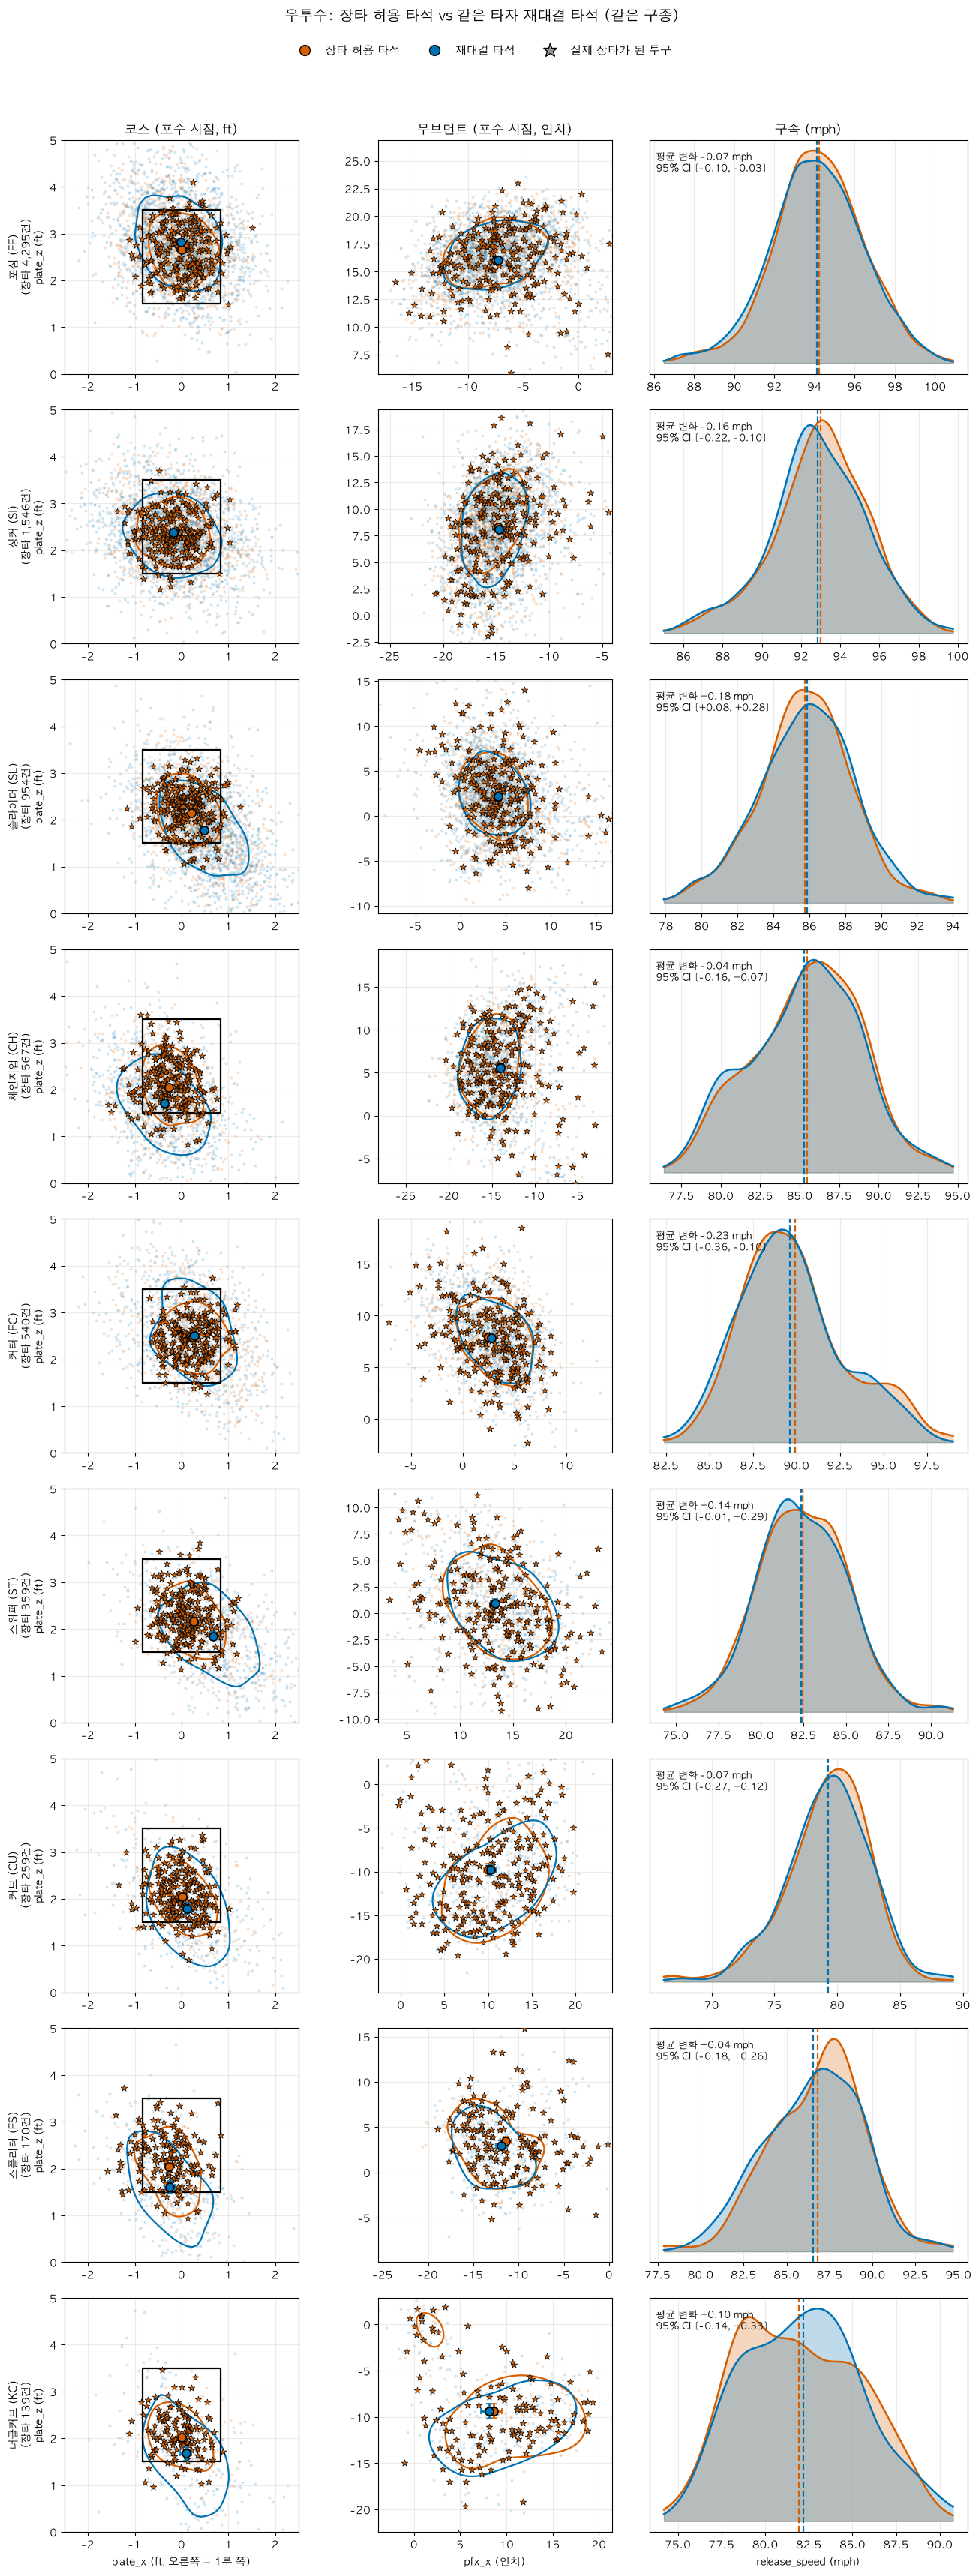

좌투수: 그린 구종 ['FF', 'SI', 'CH', 'SL', 'FC', 'CU', 'ST']


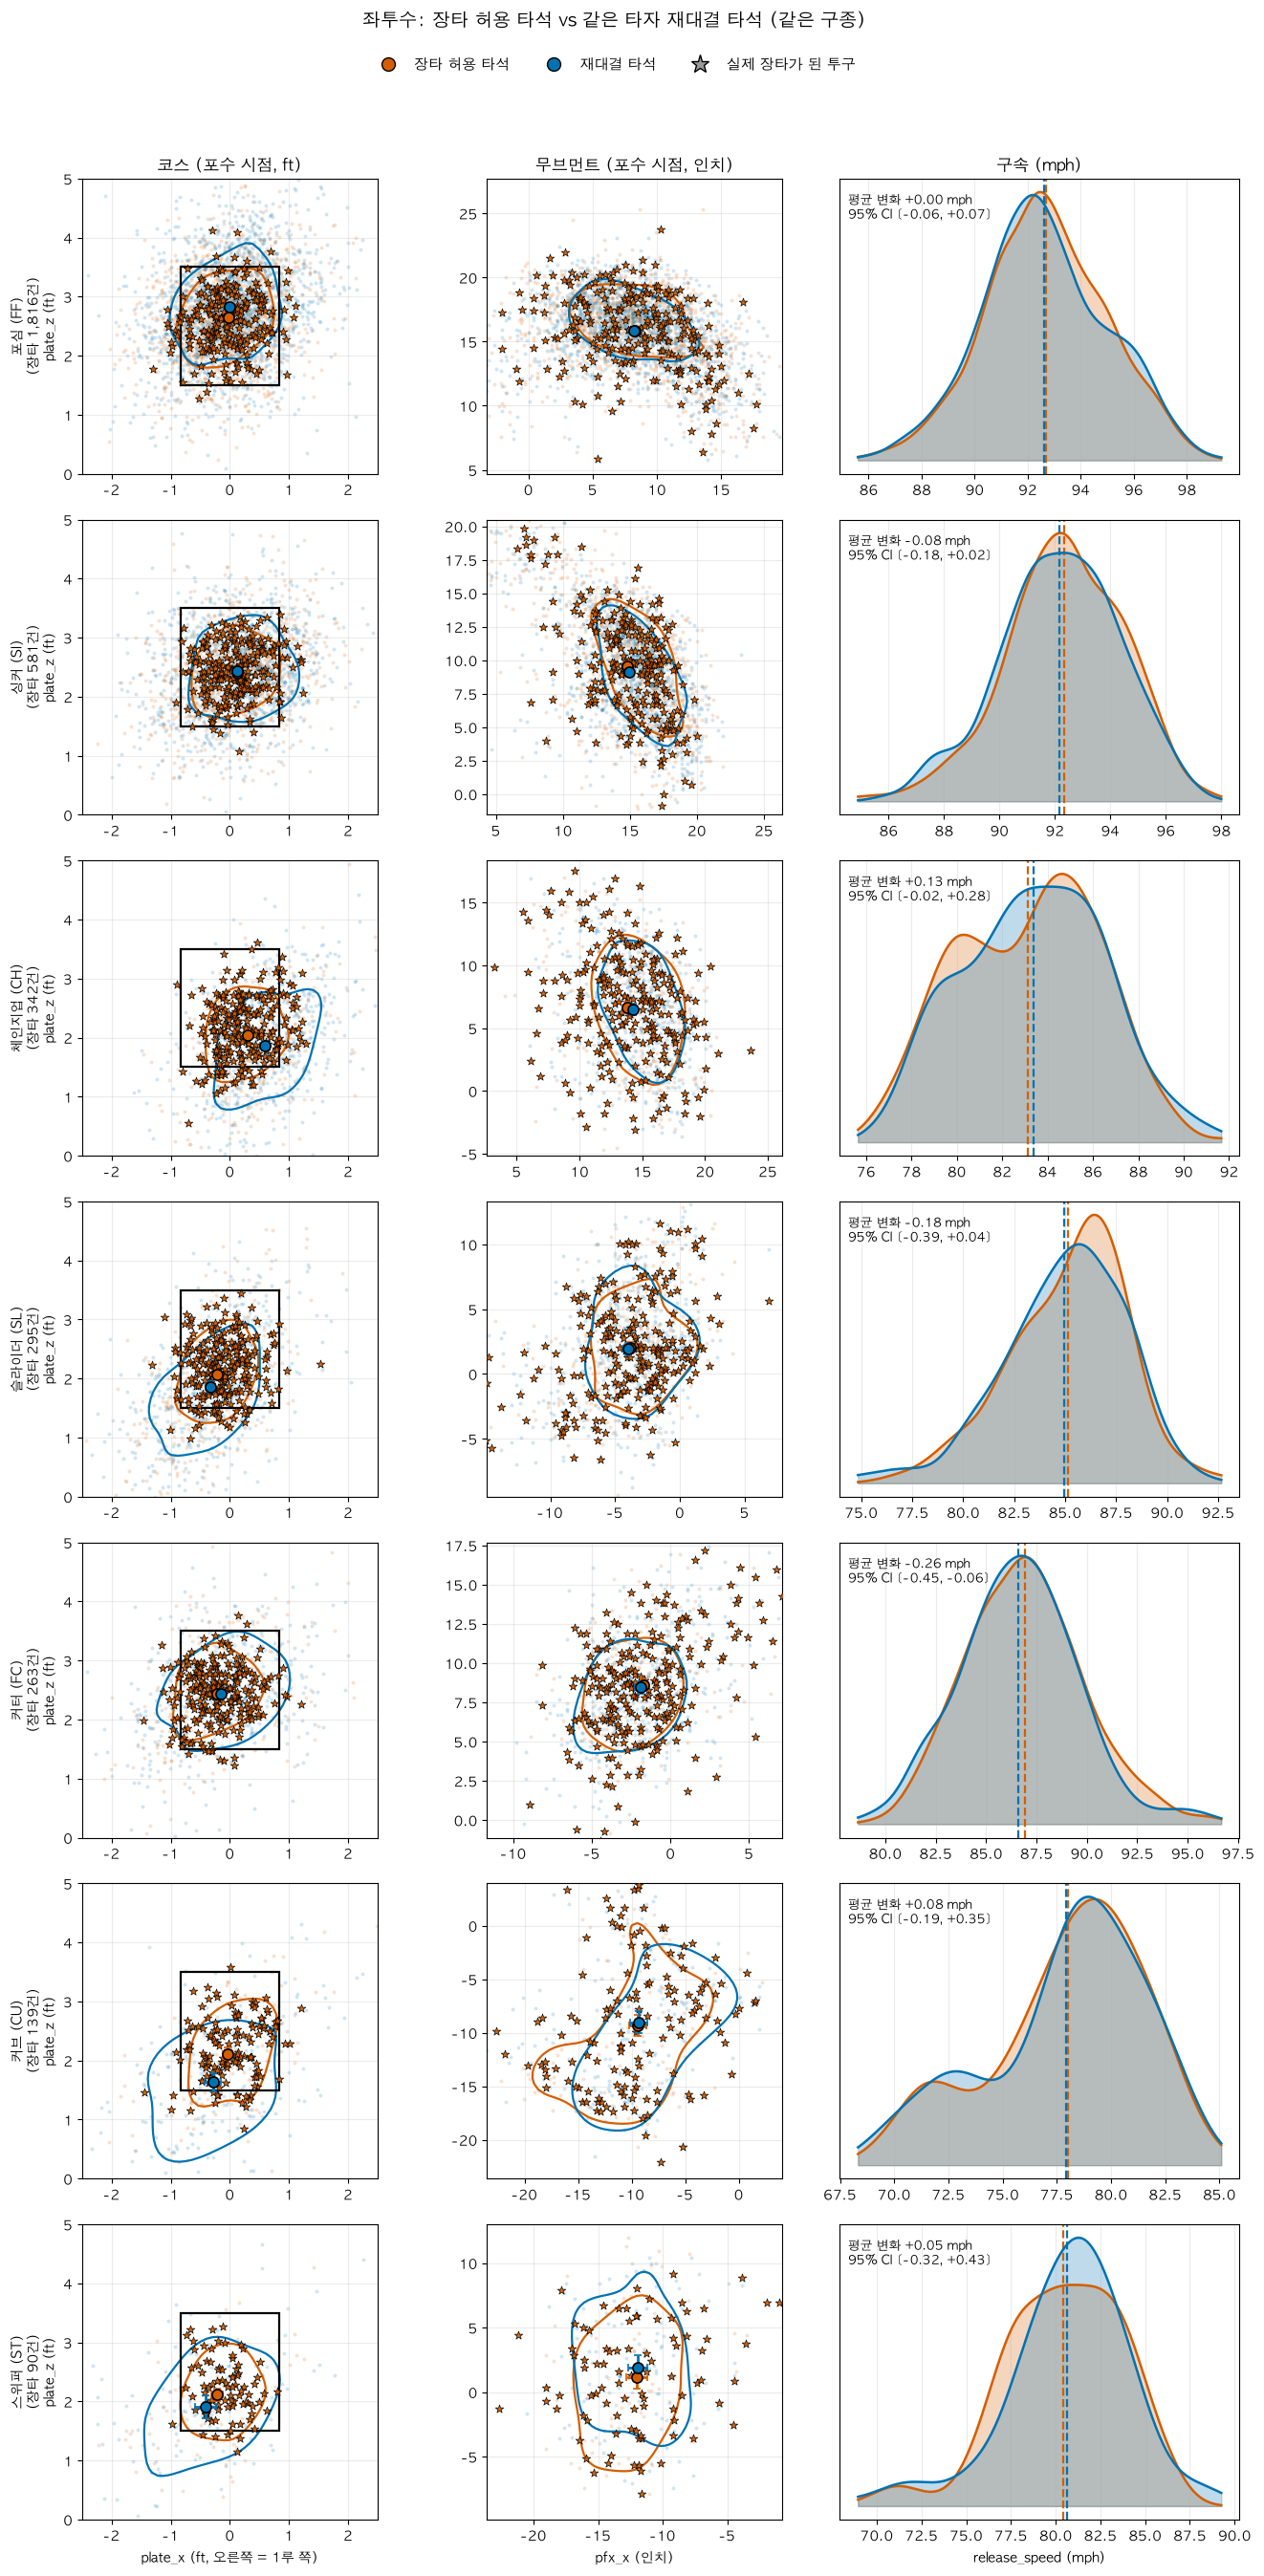

이벤트 50건 미만이라 그리지 않은 구종 (수치표에는 있음):


,p_throws,hit_pitch_type,n_events
4,L,FS,13
5,L,KC,30
9,L,SV,16
14,R,FO,6
17,R,KN,11
21,R,SV,28


In [11]:
FIGURE_DIR = Path('../data/processed/figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

for hand, name in (('R', 'RHP'), ('L', 'LHP')):
    fig, types = plot_hand_figure(pa, hand)
    fig.savefig(FIGURE_DIR / f'rematch_execution_{name}.png', dpi=130)
    print(f'{HAND_LABELS[hand]}: 그린 구종 {types}')
    plt.show()

drawn = {h: set(pa[pa['p_throws'] == h].groupby('hit_pitch_type')['event_id'].nunique().loc[lambda s: s >= 50].index) for h in 'RL'}
omitted = (
    pa.groupby(['p_throws', 'hit_pitch_type'])['event_id'].nunique().rename('n_events').reset_index()
    .loc[lambda d: d.apply(lambda r: r['hit_pitch_type'] not in drawn[r['p_throws']], axis=1)]
)
print('이벤트 50건 미만이라 그리지 않은 구종 (수치표에는 있음):')
display(omitted)

## 5. 관찰 (수치표 기준, 이벤트 단위 평균 변화 = 재대결 타석 − 장타 허용 타석, 95% CI)

포수 시점에서 `plate_x`가 양수면 오른쪽(1루 쪽)입니다. 우투수의 글러브 쪽은 포수 시점 오른쪽(+), 팔 쪽은 왼쪽(−)이고 좌투수는 반대입니다.

* **높낮이(`plate_z`)가 가장 뚜렷하게 달라졌고, 우투·좌투에서 같은 방향입니다.**
  * 포심(FF)은 재대결에서 **높아졌습니다**: 우투 +0.17 ft [+0.14, +0.19], 좌투 +0.18 ft [+0.15, +0.22].
  * 슬라이더·체인지업·커브·스위퍼 등 변화구와 오프스피드는 **낮아졌습니다**: 우투 SL −0.36 ft [−0.41, −0.30], CH −0.35 ft [−0.43, −0.27], ST −0.31 ft [−0.41, −0.21], CU −0.26 ft [−0.39, −0.13],
    좌투 SL −0.20 ft [−0.30, −0.10], CH −0.19 ft [−0.28, −0.09], CU −0.48 ft [−0.64, −0.31] (좌투 ST는 표본 90건으로 신뢰구간이 0을 포함).
  * 싱커(SI)와 커터(FC)는 높낮이 변화가 뚜렷하지 않습니다(신뢰구간이 0을 포함).
* **좌우 위치도 구종별로 우투·좌투가 거울처럼 대칭입니다.**
  * 슬라이더·스위퍼·커브는 **글러브 쪽으로** 더 갑니다: 우투 SL +0.27 ft [+0.22, +0.32], ST +0.41 ft [+0.32, +0.51](+가 글러브 쪽), 좌투 SL −0.11 ft [−0.19, −0.02], CU −0.25 ft [−0.39, −0.11](−가 글러브 쪽). 우투 CU(+0.09 ft)와 좌투 ST(−0.20 ft)도 같은 방향이지만 신뢰구간이 0을 포함합니다.
  * 체인지업은 **팔 쪽으로** 더 갑니다: 우투 CH −0.10 ft [−0.18, −0.03], 좌투 CH +0.30 ft [+0.21, +0.38].
  * 포심과 싱커는 좌우 변화가 없습니다(신뢰구간이 0을 포함).
* **구속 변화는 작습니다.** 대부분 ±0.3 mph 안이고 신뢰구간이 0을 포함하는 구종이 많습니다. 뚜렷한 것은 우투 FF −0.07 mph [−0.10, −0.03], SI −0.16 mph [−0.22, −0.10], FC −0.23 mph [−0.36, −0.10],
  좌투 FC −0.26 mph [−0.45, −0.06]처럼 소폭 감소이고, 우투 SL은 +0.18 mph [+0.08, +0.28]로 소폭 증가입니다.
* **무브먼트와 회전수는 대체로 뚜렷한 변화가 없습니다.** 예외로 싱커의 수직 무브먼트가 더 가라앉았고(우투 −0.22 in [−0.35, −0.10], 좌투 −0.48 in [−0.68, −0.27]), 우투 FF와 FC의 수평 무브먼트가 +0.25 in, +0.29 in 커졌습니다.
* **익스텐션(릴리스 지점)은 대부분 구종에서 +0.1–0.7 인치 커졌습니다**(예: 우투 FF +0.25 in [+0.20, +0.31], 우투 SL +0.63 in [+0.50, +0.76]). 크기는 작지만 방향이 일관되어서 눈여겨볼 만합니다. 원인은 이 노트북에서 알 수 없습니다.
* 그리지 않은 구종(FS·KC의 좌투 등 표본 50건 미만)은 수치표에만 있고 신뢰구간이 넓어 해석하지 않았습니다.

## 6. 한계

* **대조군이 없습니다.** 변화가 "장타에 대한 반응"이라고 단정할 수 없습니다. 경기가 진행되며 나타나는 자연스러운 변화(피로, 이닝 경과 등)와 장타에 대한 반응을 이 노트북만으로는 구분할 수 없습니다.
* **선택 편향:** 장타가 된 투구는 실투(가운데로 몰린 공 등)였을 가능성이 있고, 장타 허용 타석 평균에는 그 투구가 포함되어 있어 위치 변화의 일부가 이 투구 때문일 수 있습니다(별표로 구분). 그 투구를 뺀 비교는 하지 않았습니다.
* **고정 스트라이크 존:** 타자별 존 상하한이 데이터에 없어 고정 사각형으로 그렸습니다.
* **타자 좌/우 혼합:** 좌·우타자를 섞어 그려서 코스 분포가 넓어 보일 수 있습니다. 한 이벤트의 두 타석은 같은 타자라 이벤트 안 비교는 공정합니다.
* **카운트·상황 미통제:** 장타 허용 타석과 재대결 타석의 카운트 분포·주자 상황이 다를 수 있습니다(예: 카운트에 따라 구종의 높낮이가 달라짐).